## Imports

In [29]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import EMOTION_LABELS, IMAGE_SIZE

## Data Loading and Split

In [30]:
csv_path = Path("../data/raw/fer2013/fer2013.csv")
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [31]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']


In [32]:
train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (28709, 3)
Validation: (3589, 3)
Test: (3589, 3)


## Class Distribution

In [38]:
class_counts = train_df["emotion"].value_counts().sort_index()
class_counts.index = class_counts.index.map(EMOTION_LABELS)

class_counts

emotion
Angry       3995
Disgust      436
Fear        4097
Happy       7215
Sad         4830
Surprise    3171
Neutral     4965
Name: count, dtype: int64

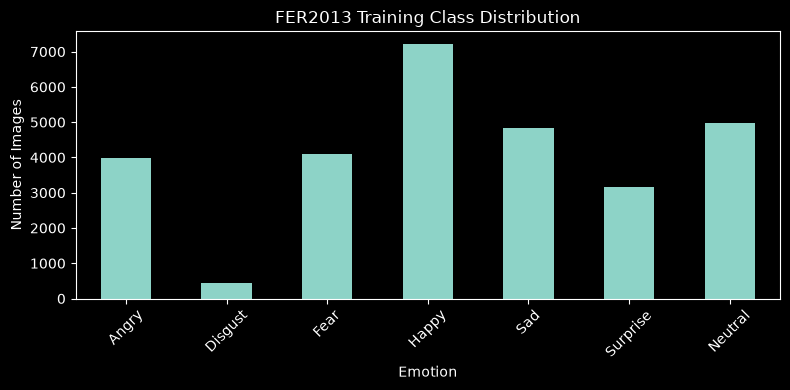

In [39]:
plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("FER2013 Training Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/training_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Pixel Values and Normalization

In [40]:
pixels = np.fromstring(train_df.iloc[0]["pixels"], sep=" ", dtype=np.float32)

print("Single image pixel count:", pixels.size)
print("Expected:", IMAGE_SIZE * IMAGE_SIZE)

Single image pixel count: 2304
Expected: 2304


In [41]:
all_train_pixels_raw = []

for pixel_string in train_df["pixels"]:
    pixels = np.fromstring(pixel_string, sep=" ", dtype=np.float32)
    all_train_pixels_raw.append(pixels)

all_train_pixels_raw = np.concatenate(all_train_pixels_raw)

print("Training pixel min:", all_train_pixels_raw.min())
print("Training pixel max:", all_train_pixels_raw.max())

Training pixel min: 0.0
Training pixel max: 255.0


In [42]:
all_train_pixels = all_train_pixels_raw / 255.0

train_mean = all_train_pixels.mean()
train_std = all_train_pixels.std()

print("Training mean:", train_mean)
print("Training std:", train_std)

Training mean: 0.5077426
Training std: 0.25500894


## Sample images

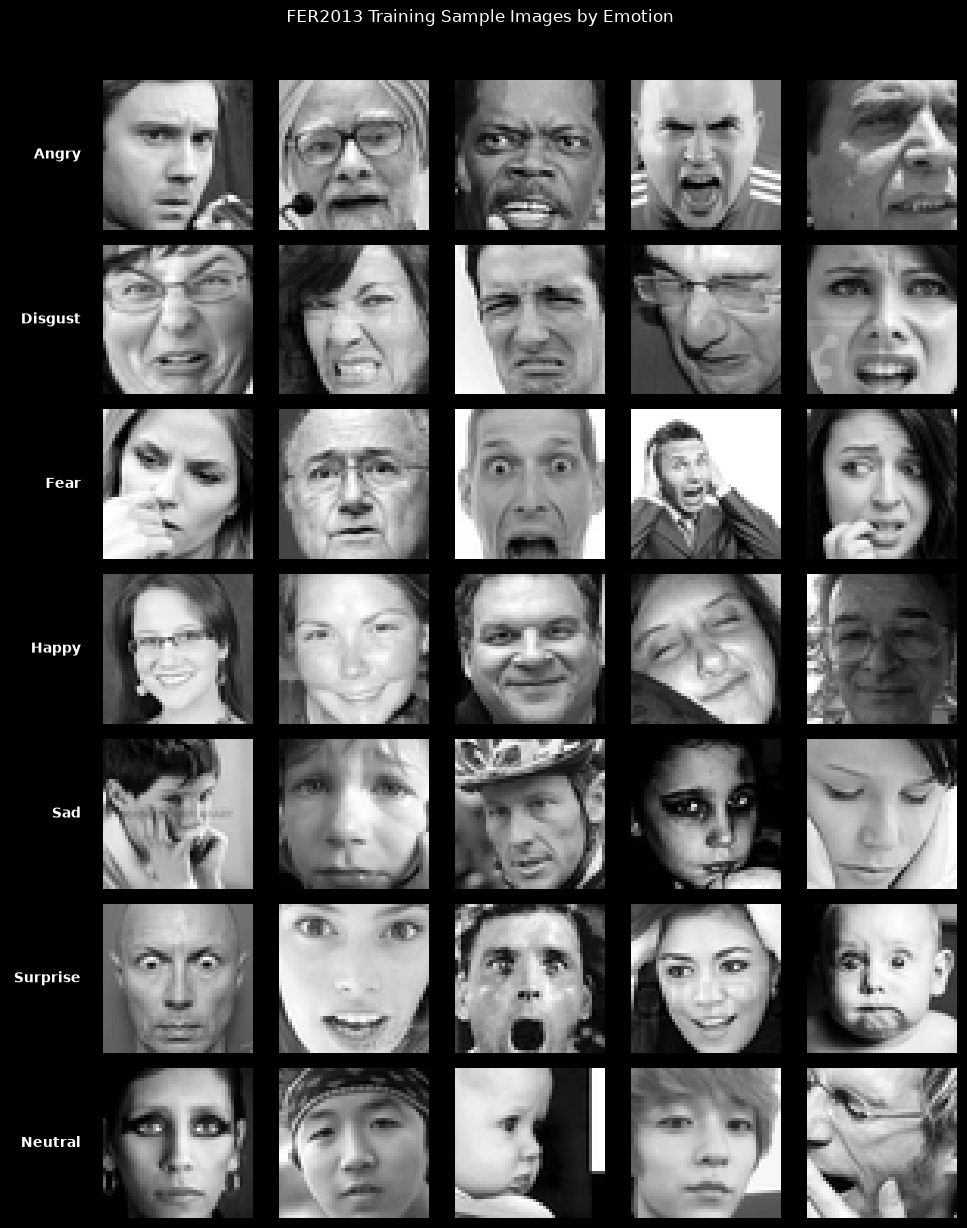

In [37]:
num_samples_per_class = 5

fig, axes = plt.subplots(
    len(EMOTION_LABELS),
    num_samples_per_class + 1,
    figsize=(10, 12),
    gridspec_kw={"width_ratios": [0.45] + [1] * num_samples_per_class}
)

for class_id, emotion_name in EMOTION_LABELS.items():
    label_ax = axes[class_id, 0]
    label_ax.axis("off")
    label_ax.text(
        0.95,
        0.5,
        emotion_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    class_df = train_df[train_df["emotion"] == class_id].head(num_samples_per_class)

    for col_idx, (_, row) in enumerate(class_df.iterrows()):
        pixels = np.fromstring(row["pixels"], sep=" ", dtype=np.float32)
        image = pixels.reshape(IMAGE_SIZE, IMAGE_SIZE)

        ax = axes[class_id, col_idx + 1]
        ax.imshow(image, cmap="gray")
        ax.axis("off")

plt.suptitle("FER2013 Training Sample Images by Emotion", y=1.02)
plt.tight_layout()

plt.savefig("../images/training_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()